This book post-processes the experimental measurements of laser beam profiles and the results of LID measurements.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Laser spatial profile

The measured sparial distribution of laser intensity is close to the gaussian distribution. For both duration of the laser pulse, a single gaussian distribution was used with FWHM=1 mm.

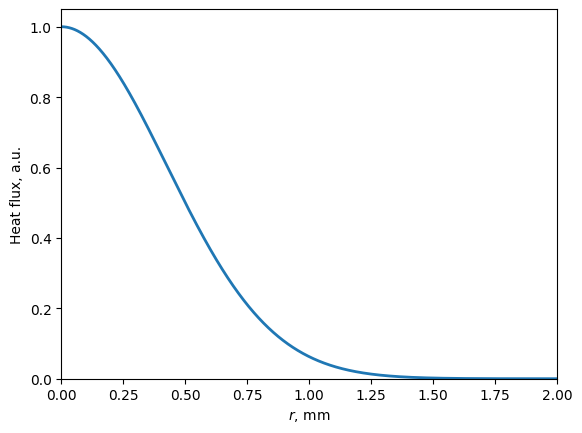

In [2]:
FWHM = 1e-3
sigma_r = FWHM / 2 / np.sqrt(2 * np.log(2))

profile = lambda r: 1 * np.exp(-(r**2) / 2 / sigma_r**2)
r = np.linspace(0, 2e-3, num=10000)

plt.plot(r / 1e-3, profile(r), lw=2)

plt.xlabel(r"$r$, mm")
plt.ylabel("Heat flux, a.u.")
plt.xlim(0, 2)
plt.ylim(0,1.05)
plt.show()

## Laser temporal profiles

Two duration of laser pulse were used: 1 millisecond and 250 microsecond. We must note that the measured duration of the pulse shell is shorter approximately by 80 microseconds due to the peculiarity of the laser system. For simulations, the measured temporal dependencies were fitted by piece-wise smooth functions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

mpl_params = {
    "axes.spines.right": False,
    "axes.spines.top": False,
}

plt.rcParams.update(mpl_params)

def fit_func(t, t1, t2, dt1, delta, dt2):
    """
    This function defines a trapezoid-like pulse with exponential leading and trailing edges

    :param t: time
    :type t: s
    """

    return np.piecewise(
        t,
        [t <= t1, (t > t1) & (t <= t2), t > t2],
        [
            lambda t: 1 / (1 + np.exp(-(t - 0.5 * t1) / dt1)),
            lambda t: 1
            / (1 + np.exp(-(t1 - 0.5 * t1) / dt1))
            * (1 - delta * (t - t1) / (t2 - t1)),
            lambda t: 1
            / (1 + np.exp(-(t1 - 0.5 * t1) / dt1))
            * (1 - delta)
            * np.exp(-(t - t2) / dt2),
        ],
    )

durations = ["1ms", "250us"]
popts = []
datas = []

for i, duration in enumerate(durations):
    data = np.loadtxt(f"./temporal_profiles/TimeProfile_{duration}.csv", delimiter=",", skiprows=1)
    datas.append(data)

    popt, _ = curve_fit(
        fit_func, data[:, 0], data[:, 1], p0=[1e-4, 170e-6, 1e-6, 0, 2e-4]
    )
    popts.append(popt)

    times = np.linspace(0, 10e-3, 100000)
    integral = np.trapz(fit_func(times, *popt), x=times)
    print(f"Fitting parametrs for {duration}: {popt}, integral = {integral:.5e} s")

/tmp/ipykernel_19282/4007319529.py:24: RuntimeWarning: overflow encountered in exp
  lambda t: 1 / (1 + np.exp(-(t - 0.5 * t1) / dt1)),


Fitting parametrs for 1ms: [2.00546390e-04 1.01122930e-03 3.38692000e-07 3.23973617e-02
 1.97812839e-04], integral = 1.08923e-03 s
Fitting parametrs for 250us: [1.15673171e-04 2.19229191e-04 3.71988035e-06 1.89739539e-02
 1.82511663e-05], integral = 1.78315e-04 s


/tmp/ipykernel_19282/4007319529.py:24: RuntimeWarning: overflow encountered in exp
  lambda t: 1 / (1 + np.exp(-(t - 0.5 * t1) / dt1)),


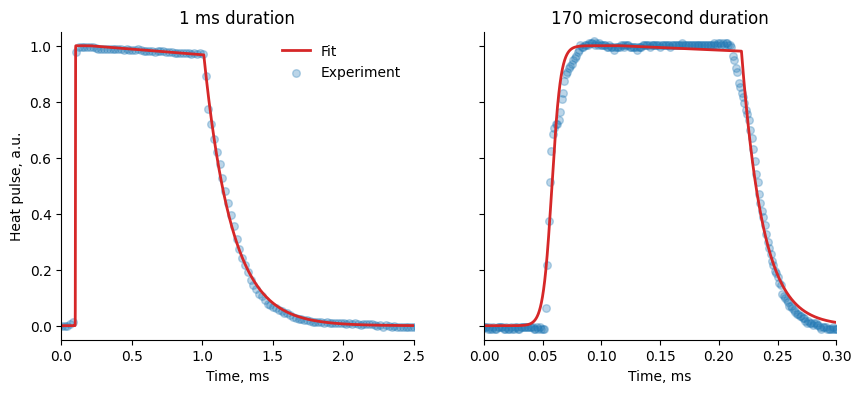

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)

titles = ["1 ms duration", "170 microsecond duration"]
for i, duration in enumerate(durations):
    N = int(len(datas[i]) / 250)
    
    axs[i].plot(datas[i][:, 0]/1e-3, fit_func(datas[i][:, 0], *popts[i]), label="Fit", lw=2, color="tab:red")
    axs[i].scatter(datas[i][::N, 0]/1e-3, datas[i][::N, 1], label="Experiment", s=30, alpha=0.3)
    
    
    axs[i].set_xlabel("Time, ms")
    axs[i].set_title(titles[i])


axs[0].legend(frameon=False)
axs[0].set_ylabel("Heat pulse, a.u.")
axs[0].set_ylim(-0.05,1.05)
axs[0].set_xlim(0, 2.5)
axs[1].set_xlim(0, 0.3)
plt.show()

## LID data

Experiments involved a series of laser irradiations of W films with varying beam energy. At each beam energy, multiple laser shots to the same area were performed. In the present work, only first pulse for each laser energy are used.

9.465876100628933e-10


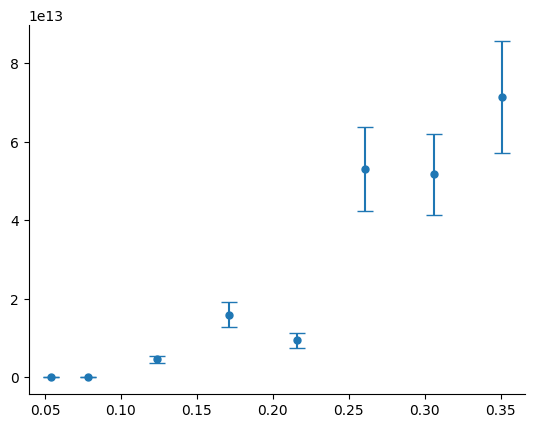

9.465876100628933e-10


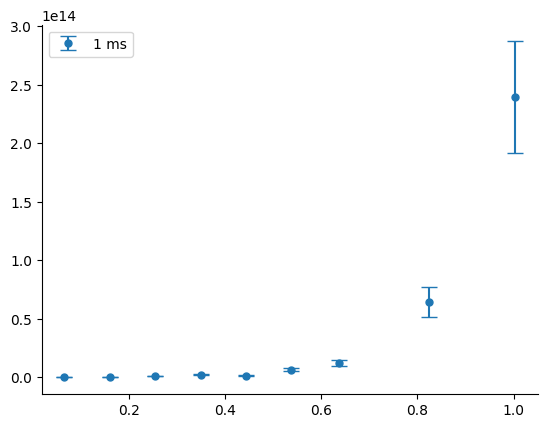

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

pd.options.mode.chained_assignment = None


def get_leak(leak_file):
    """
    Evaluates the QMS signal corresponding to the leak

    :param leak_file: name of a file containing the raw data
    :type leak_file: str
    :return: leak value
    :rtype: float
    """
    data = pd.read_csv(leak_file, skiprows=328, header=None, sep=",").dropna(axis=1)

    data[0] = pd.to_datetime(data[0])
    data[0] = (data[0] - data[0][0]).dt.total_seconds()

    mass3 = data[data[1] == 3.0].reset_index(drop=True).drop(columns=1)
    mass4 = data[data[1] == 4.0].reset_index(drop=True).drop(columns=1)
    mass3 = mass3.rename(columns={0: "Time, s", 2: f"Signal, A"})
    mass4 = mass4.rename(columns={0: "Time, s", 2: f"Signal, A"})
    # mass3.to_csv("M3.csv")
    # mass4.to_csv("M4.csv")

    #plt.plot(mass3["Time, s"], mass3["Signal, A"])
    #plt.plot(mass4["Time, s"], mass4["Signal, A"])
    #plt.yscale("log")
    #leak = mass4["Signal, A"][mass4["Time, s"] > 80].mean()

    print(leak)
    return leak


def pp(datas, leak, is_plot=True):
    """

    :param datas: _description_
    :type datas: _type_
    :param leak: _description_
    :type leak: _type_
    :param is_plot: _description_, defaults to True
    :type is_plot: bool, optional
    :return: _description_
    :rtype: _type_
    """
    period = 10
    k = 1.57005e14
    # leak = 9.47e-10

    cutted_data = []
    fluences = []
    max_t = datas[1]["Time, s"][
        datas[1]["Signal, A"] == max(datas[1]["Signal, A"])
    ].iloc[0]

    for i, data in enumerate(datas):
        data = data.rolling(10).mean()

        data["Signal, A"] = (
            data["Signal, A"] - data["Signal, A"][data["Time, s"] <= 1].mean()
        )
        noise_max = data["Signal, A"][data["Time, s"] <= 2].max()

        cutted = data[
            (data["Time, s"] <= max_t + period * 2 / 3) & (data["Time, s"] > max_t - 2)
        ]

        if is_plot:
            (l1,) = plt.plot(
                cutted["Time, s"],
                cutted["Signal, A"] * k / leak / 2 * (i + 1),
                label=f"Масса: {i+3}",
            )
            plt.axhline(noise_max, ls="dashed", color=l1.get_color())

        if noise_max * 5 >= cutted["Signal, A"].max():
            fluences.append(0)
        else:
            left_tzero = cutted["Time, s"][
                (cutted["Time, s"] < max_t) & (cutted["Signal, A"] <= 0)
            ].iloc[-1]
            try:
                right_tzero = cutted["Time, s"][
                    (cutted["Time, s"] > max_t) & (cutted["Signal, A"] <= 0)
                ].iloc[0]
            except:
                right_tzero = cutted["Time, s"].max()

            fluences.append(
                np.trapz(
                    y=cutted["Signal, A"][
                        (cutted["Time, s"] >= left_tzero)
                        & (cutted["Time, s"] <= right_tzero)
                    ],
                    x=cutted["Time, s"][
                        (cutted["Time, s"] >= left_tzero)
                        & (cutted["Time, s"] <= right_tzero)
                    ],
                )
                * k
                / leak
                / 2
                * (i + 1)
            )
            if is_plot:
                plt.axvline(left_tzero, ls="dashed", color=l1.get_color())
                plt.axvline(right_tzero, ls="dashed", color=l1.get_color())
    if is_plot:
        plt.axhline(0, ls="dashed", color="black")
        plt.xlabel("Время, с")
        plt.ylabel("Поток D, ат/с")
        plt.legend()
        plt.show()
        print(fluences)
    return cutted_data, fluences


def get_fluences(folder, name, leak):
    for file in sorted(os.listdir(folder)):
        filename = os.fsdecode(file)
        if filename.endswith(".csv") and filename.startswith(name):
            data = pd.read_csv(
                folder + filename, skiprows=328, header=None, sep=","
            ).dropna(axis=1)

            data[0] = pd.to_datetime(data[0])
            data[0] = (data[0] - data[0][0]).dt.total_seconds()

            mass3 = data[data[1] == 3.0].reset_index(drop=True).drop(columns=1)
            mass4 = data[data[1] == 4.0].reset_index(drop=True).drop(columns=1)
            mass3 = mass3.rename(columns={0: "Time, s", 2: f"Signal, A"})
            mass4 = mass4.rename(columns={0: "Time, s", 2: f"Signal, A"})

            separated_data = [mass3, mass4]

            separated_data, fluence_1 = pp(separated_data, leak, False)

            F = 0
            for i, fl in enumerate(fluence_1):
                if fl >= 0:
                    F += fl

            fluences.append(F)
    return fluences


folder = "./LID_data/250 mks/"
name = "50824"
fluences = []

leak = get_leak(folder + "leak.csv")
fluences = get_fluences(folder, name, leak)
energies = [0.054, 0.078, 0.124, 0.171, 0.216, 0.261, 0.306, 0.351]  # 250 us
# fluences = [0, 0, 5133716691344.515, 18532887681986.27, 10540481234968.29, 60643751401553.06, 59098320981498.01, 81554457549307.39]

plt.errorbar(
    energies,
    np.array(fluences),
    yerr=np.array(fluences) * 0.20,
    fmt="o",
    markersize=5,
    capsize=6,
    label="250 us",
    # s=25,
)
plt.show()

folder = "./LID_data/1 ms/"
name = "60824"
fluences = []

leak = get_leak(folder + "leak.csv")
fluences = get_fluences(folder, name, leak)
energies = [0.066, 0.16, 0.255, 0.34951, 0.444, 0.53771, 0.636, 0.823, 1.003]  # 1 ms
# fluences = [0, 0, 1054478097062.3062, 2401476299662.052, 1507355677569.9465, 6853539178657.508, 12628691889725.508, 64106569074151.78, 239789819543843.44]

plt.errorbar(
    energies,
    np.array(fluences),
    yerr=np.array(fluences) * 0.20,
    fmt="o",
    markersize=5,
    capsize=6,
    label="1 ms",
    # s=25,
)

# energies = [1.2987984, 2.06995995, 2.06995995, 2.06995995, 2.83714393, 3.60416556, 4.364855548, 5.16272364, 6.68069427, 8.14184247]


plt.legend()
# plt.yscale("log")
plt.show()
